In [1]:
import pandas as pd

df = pd.read_csv("../data/feedback.csv")
df.head()

,student_id,course,teacher,teaching_quality,difficulty,satisfaction,hours_spent
0,1,Data Science,John,4,5,3,12
1,2,Data Science,John,5,4,4,10
2,3,Data Science,John,3,5,2,14
3,4,Math,Alex,5,3,5,8
4,5,Math,Alex,4,3,4,7


In [2]:
df.groupby("course")["satisfaction"].mean()


course
Computer Networks    4.333333
Data Science         3.000000
Math                 4.666667
Operating Systems    2.666667
Physics              2.333333
Name: satisfaction, dtype: float64

In [3]:
df.groupby("course")["difficulty"].mean()

course
Computer Networks    2.666667
Data Science         4.666667
Math                 2.666667
Operating Systems    4.666667
Physics              4.666667
Name: difficulty, dtype: float64

In [4]:
df.groupby("teacher")["teaching_quality"].mean()

teacher
Alex     4.666667
David    3.333333
John     4.000000
Mike     2.666667
Sarah    4.333333
Name: teaching_quality, dtype: float64

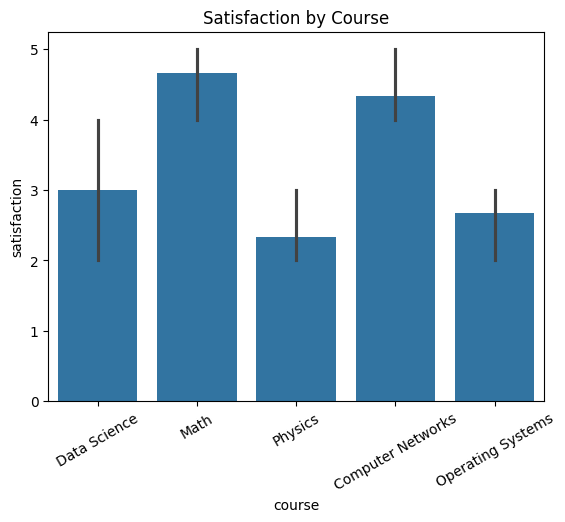

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="course", y="satisfaction", data=df)
plt.xticks(rotation=30)
plt.title("Satisfaction by Course")
plt.show()

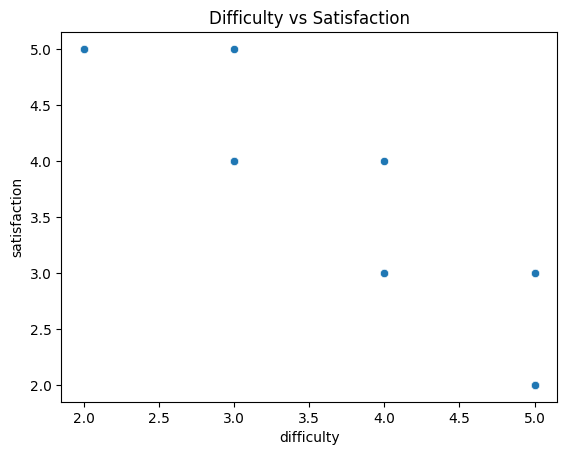

In [7]:
sns.scatterplot(x="difficulty", y="satisfaction", data=df)
plt.title("Difficulty vs Satisfaction")
plt.show()

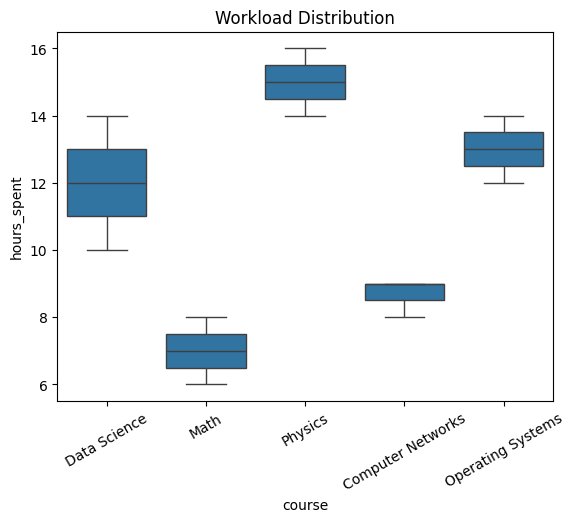

In [8]:
sns.boxplot(x="course", y="hours_spent", data=df)
plt.xticks(rotation=30)
plt.title("Workload Distribution")
plt.show()

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../scripts"))

from clean_data import load_and_clean_data

df = load_and_clean_data("../data/feedback.csv")
df.head()

,student_id,course,teacher,teaching_quality,difficulty,satisfaction,hours_spent
0,1,Data Science,John,4,5,3,12
1,2,Data Science,John,5,4,4,10
2,3,Data Science,John,3,5,2,14
3,4,Math,Alex,5,3,5,8
4,5,Math,Alex,4,3,4,7


In [2]:
import os

print(os.listdir("../scripts"))

['clean_data.py', '__pycache__']


In [3]:
df.groupby("course")["satisfaction"].mean().sort_values()

course
Physics              2.333333
Operating Systems    2.666667
Data Science         3.000000
Computer Networks    4.333333
Math                 4.666667
Name: satisfaction, dtype: float64

In [4]:
df.groupby("course")["difficulty"].mean().sort_values(ascending=False)

course
Data Science         4.666667
Physics              4.666667
Operating Systems    4.666667
Computer Networks    2.666667
Math                 2.666667
Name: difficulty, dtype: float64

In [5]:
df.groupby("teacher")["teaching_quality"].mean().sort_values(ascending=False)


teacher
Alex     4.666667
Sarah    4.333333
John     4.000000
David    3.333333
Mike     2.666667
Name: teaching_quality, dtype: float64

In [6]:
df.groupby("course")["hours_spent"].mean().sort_values(ascending=False)

course
Physics              15.000000
Operating Systems    13.000000
Data Science         12.000000
Computer Networks     8.666667
Math                  7.000000
Name: hours_spent, dtype: float64

In [7]:
summary = df.groupby("course").agg({
    "satisfaction": "mean",
    "difficulty": "mean",
    "hours_spent": "mean"
})

summary

,satisfaction,difficulty,hours_spent
course,,,
Computer Networks,4.333333,2.666667,8.666667
Data Science,3.000000,4.666667,12.000000
Math,4.666667,2.666667,7.000000
Operating Systems,2.666667,4.666667,13.000000
Physics,2.333333,4.666667,15.000000


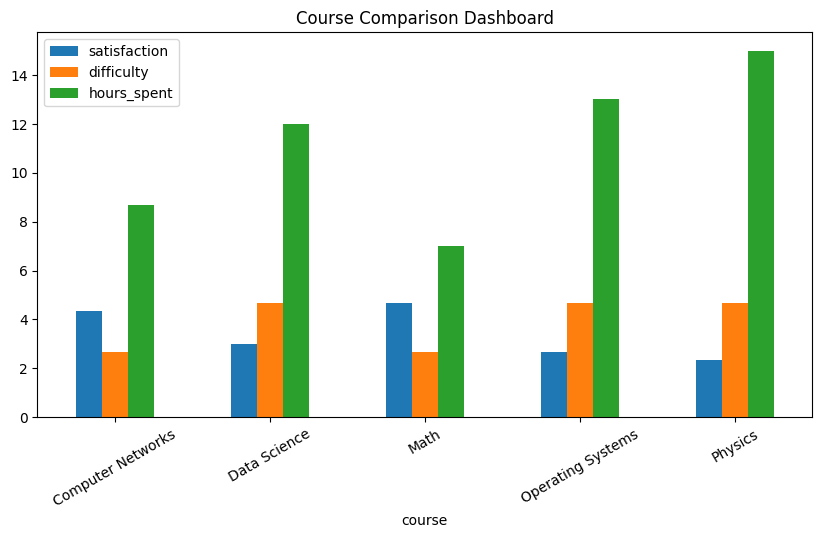

In [10]:
import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(10,5))
plt.title("Course Comparison Dashboard")
plt.xticks(rotation=30)
plt.show()

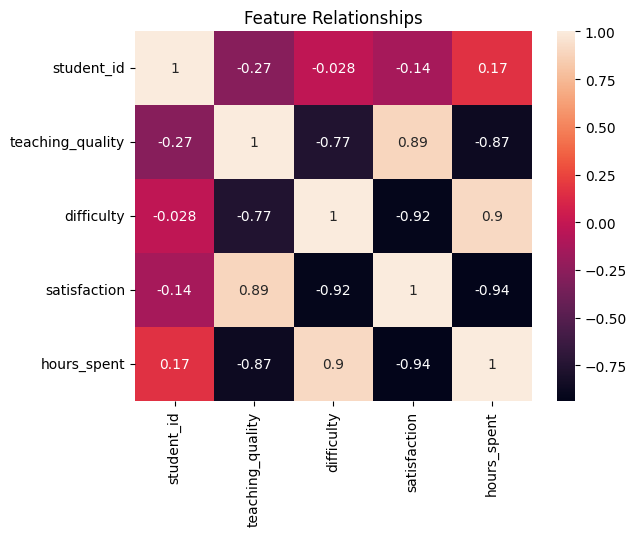

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Relationships")
plt.show()

1. Physics has the highest difficulty and workload but lowest satisfaction → needs redesign

2. Math shows high satisfaction with moderate difficulty → well-balanced course

3. Operating Systems has high workload but low satisfaction → workload optimization needed

4. Teaching quality strongly affects satisfaction → better instructors improve outcomes